In [32]:
# imports
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [33]:
# derivative of simple function
def f(x):
  return 3*x**2 - 4*x + 5

In [34]:
f(3.0)

20.0

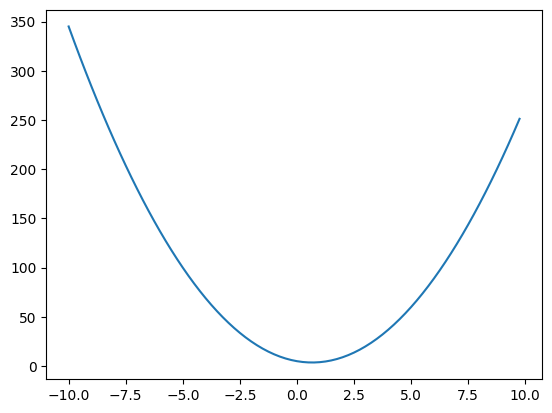

In [35]:
# plotting the function
x = np.arange(-10, 10, 0.25)
y = f(x)
plt.plot(x, y)
plt.show()

In [36]:
# if we add a small change in x, we get the slope of the function
x= 2/3
h=0.000001
(f(x+h)-f(x))/h

2.999378523327323e-06

In [37]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [38]:
h = 0.001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print("d1: ", d1)
print("d2: ", d2)

# derivative
derivative = (d2 - d1) / h
print("derivative/slope: ", derivative)


d1:  4.0
d2:  4.0009999999999994
derivative/slope:  0.9999999999994458


In [39]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
     
    def __repr__(self):
        """return a value object instead of location in memory"""
        return f"Value(data={self.data})"
    



In [40]:
Value(2.0)

Value(data=2.0)

In [43]:

class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    """return a value object instead of location in memory"""
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    """add two values"""
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out
  
  def __mul__(self, other):
    """multiply two values"""
    out = Value(self.data * other.data, (self, other), '*')
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    
    return out
  
  def tanh(self):
    """tanh of a value"""
    x = self.data
    t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1-t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()
          

In [44]:

def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)


backward(Value(2.0))

In [45]:
# Example of a simple computational graph
#      A
#    /   \
#   B     C
#    \   /
#      D

class Node:
    def __init__(self, name):
        self.name = name
        self._prev = []  # connections to previous nodes

# Create nodes
A = Node('A')
B = Node('B')
C = Node('C')
D = Node('D')

# Set up connections
B._prev = [A]    # B depends on A
C._prev = [A]    # C depends on A
D._prev = [B, C] # D depends on both B and C

# When we call backward on D, it will visit nodes in this order:
# 1. Start at D
# 2. Visit B → Visit A
# 3. Visit C → A (already visited)
# Final topological order: [A, B, C, D]
# for neural net we reverse this order

In [46]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L


Value(data=-8.0)

In [47]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

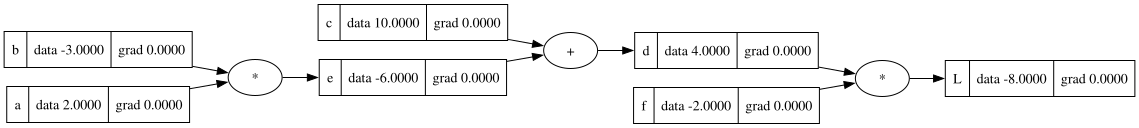

In [48]:
draw_dot(L)

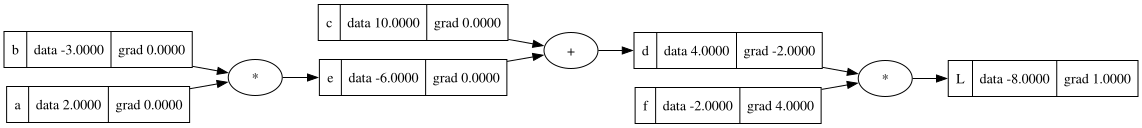

In [49]:
# let's start with the output grad = 1
L.grad = 1.0
# chain rule

d.grad = L.grad * f.data
f.grad = L.grad * d.data

draw_dot(L)


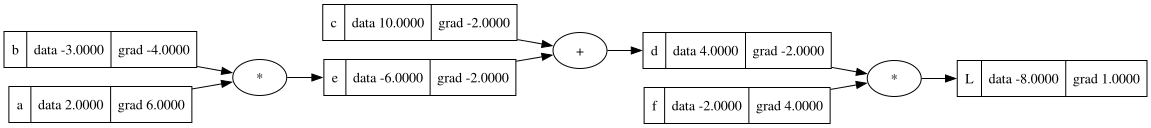

In [50]:
e.grad = d.grad * 1.0
c.grad = d.grad * 1.0

a.grad = e.grad * b.data
b.grad = e.grad * a.data

draw_dot(L)




In [51]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


In [52]:

def lol():
  
  h = 0.001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data
  
  print((L2 - L1)/h)
  
lol()

-3.9999999999995595


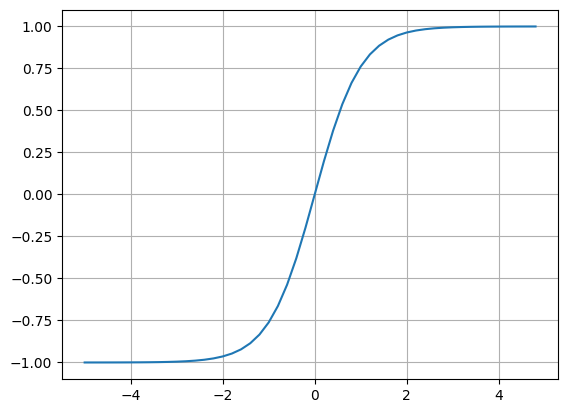

In [53]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();


In [71]:
# let's do manual backprop

# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


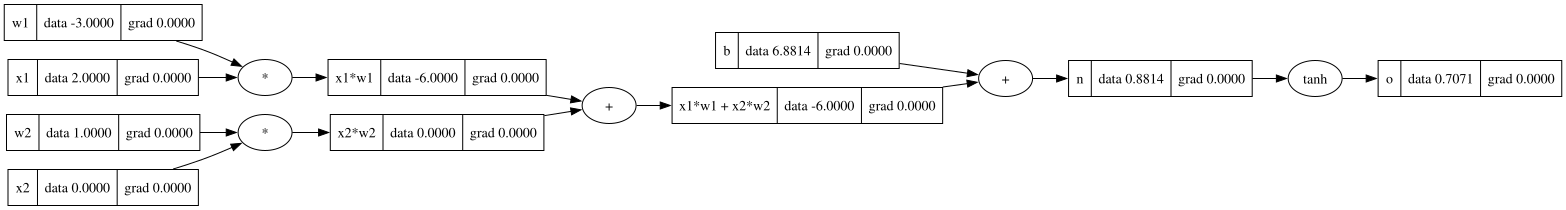

In [72]:
draw_dot(o)


In [76]:
o.backward()

In [77]:
o.grad


1.0

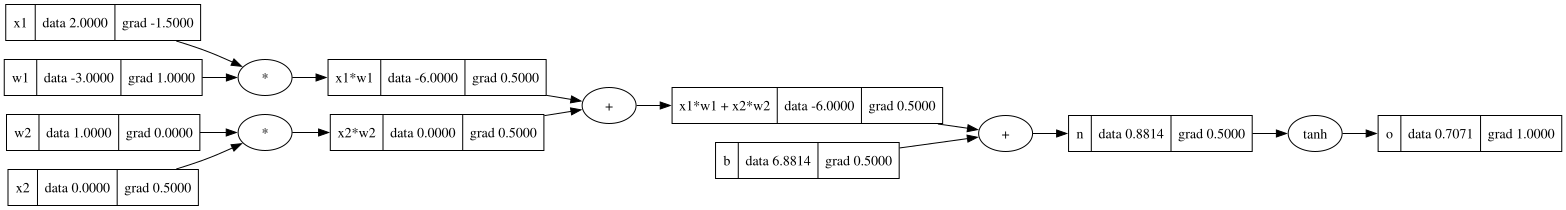

In [64]:
# after backprop
draw_dot(o)


In [57]:

topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo


[Value(data=6.881373587019543),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [80]:
# zero grads
o.grad = 0.0
n.grad = 0.0
b.grad = 0.0
w1.grad = 0.0
w2.grad = 0.0
x1.grad = 0.0
x2.grad = 0.0
x1w1x2w2.grad = 0.0
x2w2.grad = 0.0
x1w1.grad = 0.0

# update the grads
o.grad = 1.0



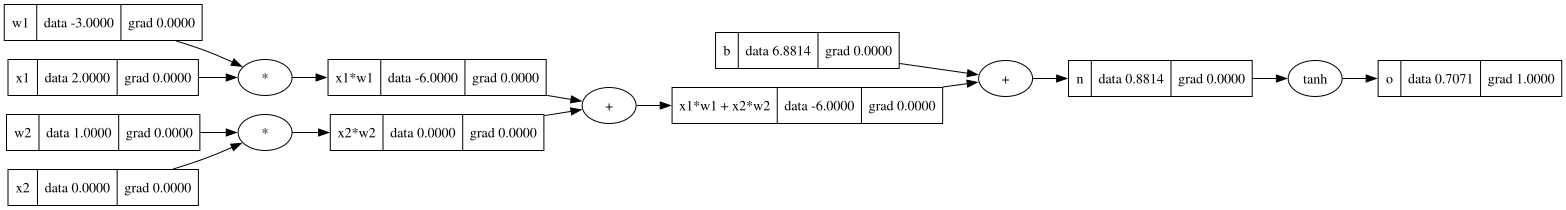

In [81]:
draw_dot(o)


In [82]:
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad


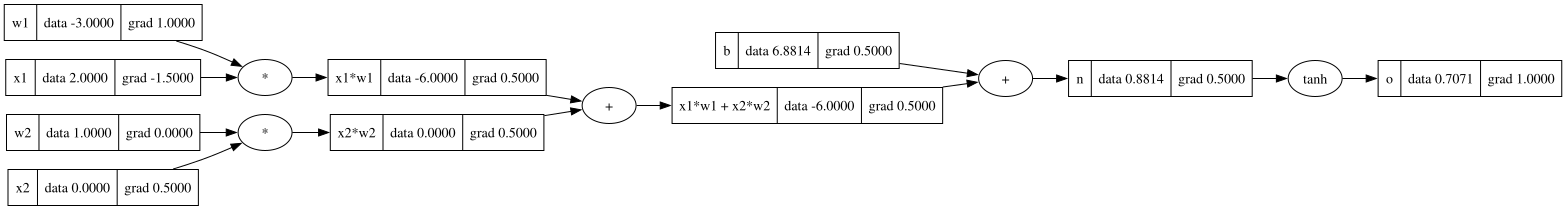

In [83]:
draw_dot(o)

In [87]:
x1w1.grad = 0.5
x2w2.grad = 0.5

x1w1x2w2.grad = 0.5
b.grad = 0.5

n.grad = 0.5

o.grad = 1.0


In [88]:
# which is the derivative of tanh
1 - o.data**2
# o = tanh(n)
# do/dn = 1 - o**2


0.4999999999999999

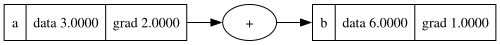

In [89]:

a = Value(3.0, label='a')
b = a + a   ; b.label = 'b'
b.backward()
draw_dot(b)


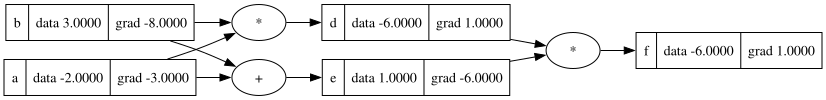

In [90]:

a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'

f.backward()

draw_dot(f)


In [91]:
# above will break are grads because in value class we do not accumulate grad, 
# let's fix that
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    """return a value object instead of location in memory"""
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    """add two values"""
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    """multiply two values"""
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def __pow__(self, other):
    """raise a value to a power"""
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out
  
  def __rmul__(self, other): # other * self
    """reverse args and multiply two values"""
    return self * other

  def __truediv__(self, other): # self / other
    """divide two values"""
    return self * other**-1

  def __neg__(self): # -self
    """negate a value"""
    return self * -1

  def __sub__(self, other): # self - other
    """subtract two values"""
    return self + (-other)

  def __radd__(self, other): # other + self
    """reverse args and add two values"""
    return self + other

  def tanh(self):
    """tanh of a value"""
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def exp(self):
    """exponential of a value"""
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    
    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    
    return out
  
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()


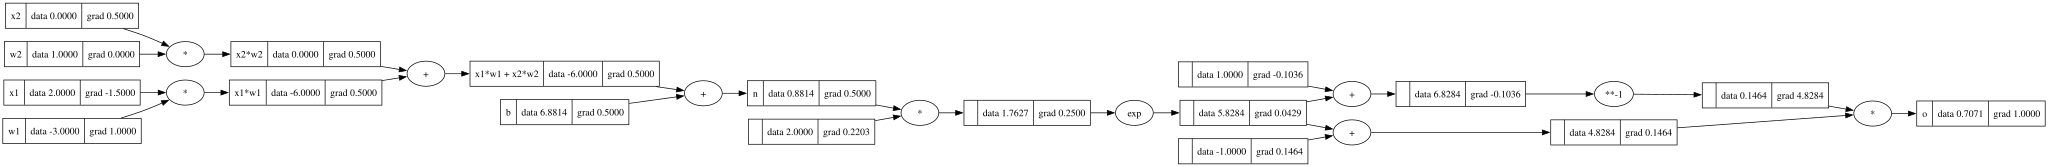

In [92]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
# splitting tanh
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)


In [93]:
import torch

# compare with torch
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())



0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [94]:
import random
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [98]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)


Value(data=-0.26702626564315274)

In [99]:

xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets


In [100]:

for k in range(20):
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    # zero grads
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)

0 5.782777331676506
1 4.846608091781858
2 4.621033637348491
3 4.054479014666564
4 3.2857785400651354
5 2.8747046981621645
6 1.8509375906708965
7 1.3323708318847622
8 0.940872469102714
9 0.7232276213930171
10 0.10957579371466855
11 0.054743746575238686
12 0.044211886307240975
13 0.037620017715597295
14 0.032835314279315395
15 0.02913726572695706
16 0.026174694613409377
17 0.023742712925500918
18 0.02170928628564168
19 0.0199839501220838
